# DSA 210 — Spotify Project
## Notebook 2: Exploratory Data Analysis (EDA)
**Selin Nardal**

Visualising listening patterns across time-of-day, day-of-week, months, and exam periods.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('data/streaming_clean.csv', parse_dates=['timestamp_local'])
df['date'] = pd.to_datetime(df['date'])
print(f'Loaded {len(df):,} rows.')
df.head(3)

Loaded 15,581 rows.


,timestamp,platform,ms_played,conn_country,ip_addr,track_name,artist,album,track_uri,episode_name,...,date,hour,day_of_week,month,is_weekend,sec_played,min_played,time_of_day,h1_group,is_exam
0,2023-10-16 15:11:32+00:00,osx,200445,TR,159.20.68.17,The Color Violet,Tory Lanez,Alone At Prom,spotify:track:3azJifCSqg9fRij2yKIbWz,NaN,...,2023-10-16,18,Monday,2023-10,False,200.445,3.34075,Evening,NaN,False
1,2023-10-16 15:11:46+00:00,osx,13296,TR,159.20.68.17,Poison,Brent Faiyaz,Poison,spotify:track:5NijSs5dAwaIybq1GaRTIe,NaN,...,2023-10-16,18,Monday,2023-10,False,13.296,0.22160,Evening,NaN,False
2,2023-10-16 15:12:25+00:00,ios,29190,TR,159.20.68.5,Starboy,The Weeknd,Starboy,spotify:track:7MXVkk9YMctZqd1Srtv4MB,NaN,...,2023-10-16,18,Monday,2023-10,False,29.190,0.48650,Evening,NaN,False


## 1. Overall Listening Over Time

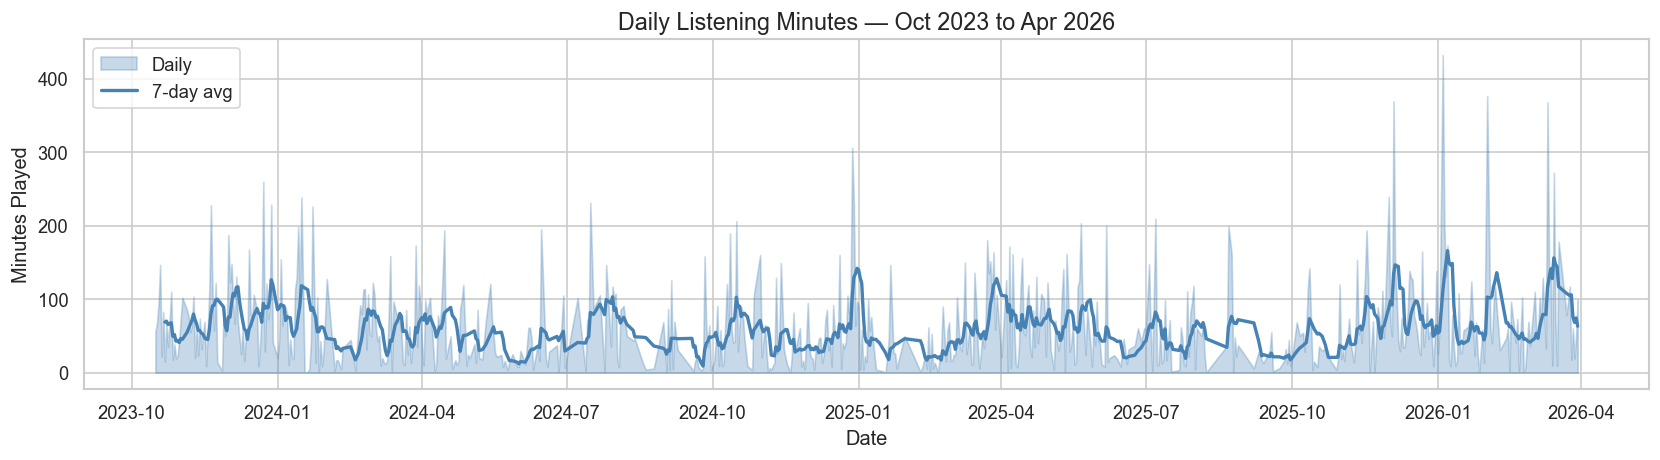

In [2]:
daily = df.groupby('date')['min_played'].sum().reset_index()
daily['rolling_7'] = daily['min_played'].rolling(7).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(daily['date'], daily['min_played'], alpha=0.3, color='steelblue', label='Daily')
ax.plot(daily['date'], daily['rolling_7'], color='steelblue', lw=2, label='7-day avg')
ax.set_title('Daily Listening Minutes — Oct 2023 to Apr 2026', fontsize=14)
ax.set_xlabel('Date'); ax.set_ylabel('Minutes Played')
ax.legend(); plt.tight_layout(); plt.savefig('figures/01_daily_listening.png', bbox_inches='tight'); plt.show()

## 2. Listening by Hour of Day (RQ1)

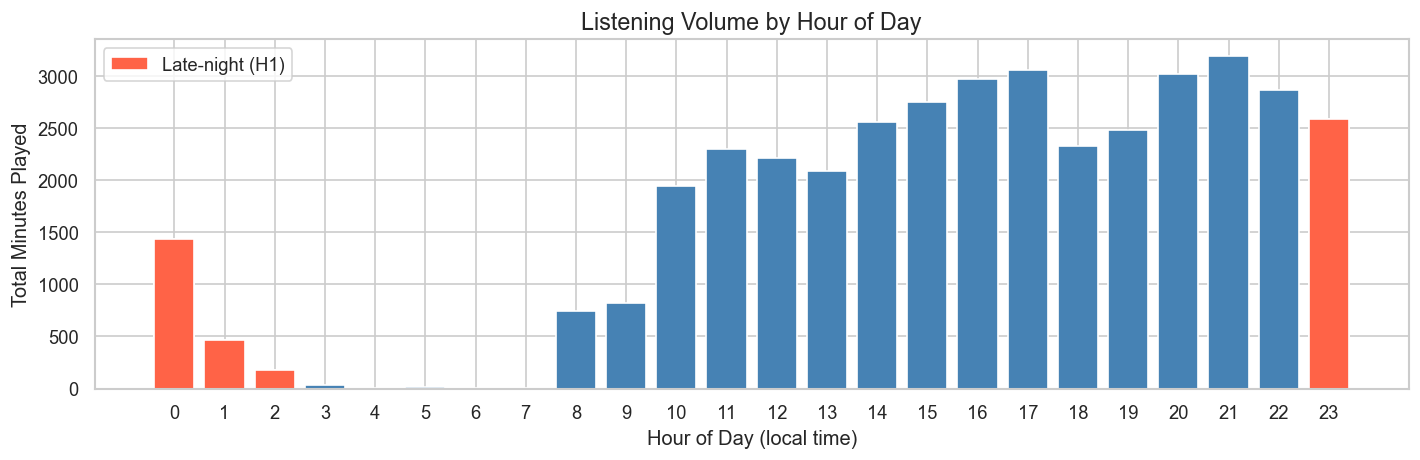

In [3]:
import os; os.makedirs('figures', exist_ok=True)

hourly = df.groupby('hour')['min_played'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(hourly['hour'], hourly['min_played'], color='steelblue', edgecolor='white')
# Highlight late-night window
for h in [23, 0, 1, 2]:
    row = hourly[hourly['hour'] == h]
    if not row.empty:
        ax.bar(h, row['min_played'].values[0], color='tomato', edgecolor='white', label='Late-night (H1)' if h==23 else '')
ax.set_xticks(range(24))
ax.set_xlabel('Hour of Day (local time)'); ax.set_ylabel('Total Minutes Played')
ax.set_title('Listening Volume by Hour of Day', fontsize=14)
ax.legend(); plt.tight_layout(); plt.savefig('figures/02_hourly.png', bbox_inches='tight'); plt.show()

## 3. Weekday vs Weekend (RQ1 / H2)

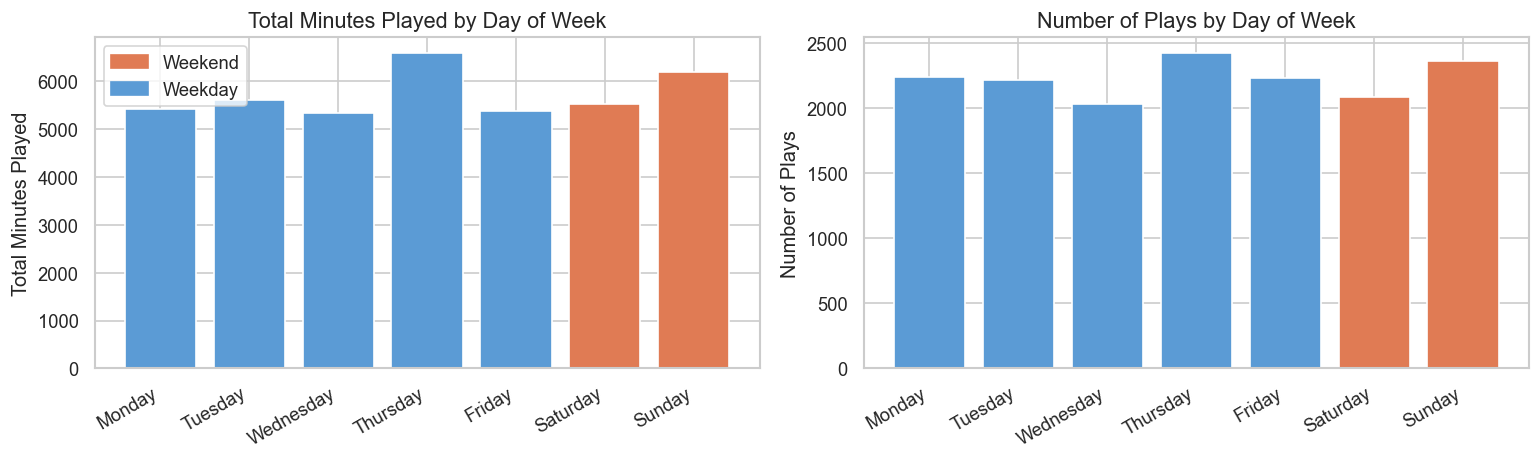

In [4]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('day_of_week').agg(
    total_min=('min_played','sum'),
    play_count=('track_name','count')
).reindex(dow_order).reset_index()

colors = ['#e07b54' if d in ['Saturday','Sunday'] else '#5b9bd5' for d in dow['day_of_week']]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in zip(axes,
                           ['total_min', 'play_count'],
                           ['Total Minutes Played', 'Number of Plays']):
    ax.bar(dow['day_of_week'], dow[col], color=colors, edgecolor='white')
    ax.set_title(f'{title} by Day of Week', fontsize=13)
    ax.set_xticklabels(dow['day_of_week'], rotation=30, ha='right')
    ax.set_ylabel(title)

from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#e07b54',label='Weekend'), Patch(color='#5b9bd5',label='Weekday')])
plt.tight_layout(); plt.savefig('figures/03_dayofweek.png', bbox_inches='tight'); plt.show()

## 4. Time-of-Day Distribution (Morning / Afternoon / Evening / Night)

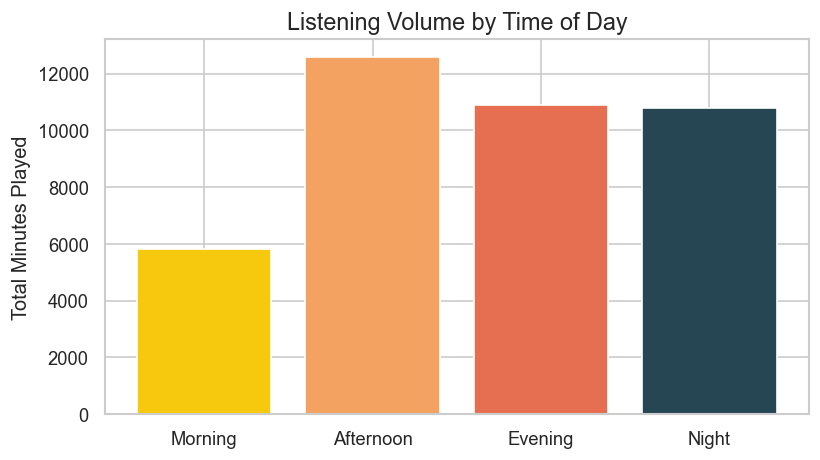

In [5]:
tod = df.groupby('time_of_day')['min_played'].sum().reindex(
    ['Morning','Afternoon','Evening','Night']).reset_index()

fig, ax = plt.subplots(figsize=(7, 4))
palette = ['#f6c90e','#f4a261','#e76f51','#264653']
ax.bar(tod['time_of_day'], tod['min_played'], color=palette, edgecolor='white')
ax.set_title('Listening Volume by Time of Day', fontsize=14)
ax.set_ylabel('Total Minutes Played')
plt.tight_layout(); plt.savefig('figures/04_time_of_day.png', bbox_inches='tight'); plt.show()

## 5. Monthly Listening Trend

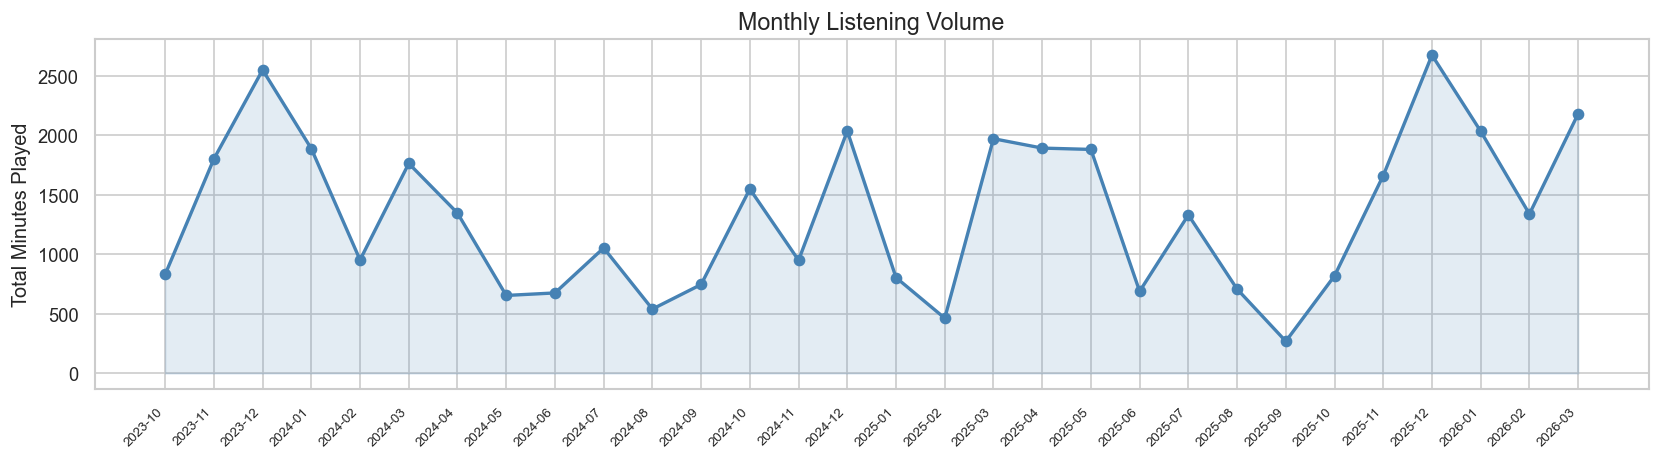

In [6]:
monthly = df.groupby('month').agg(total_min=('min_played','sum'), plays=('track_name','count')).reset_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly['month'], monthly['total_min'], marker='o', color='steelblue', lw=2)
ax.fill_between(range(len(monthly)), monthly['total_min'], alpha=0.15, color='steelblue')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['month'], rotation=45, ha='right', fontsize=8)
ax.set_title('Monthly Listening Volume', fontsize=14)
ax.set_ylabel('Total Minutes Played')
plt.tight_layout(); plt.savefig('figures/05_monthly.png', bbox_inches='tight'); plt.show()

## 6. Exam vs Non-Exam Periods (RQ2)

          plays  total_min  avg_min_per_day
is_exam                                    
Non-Exam  13565   34963.72            61.13
Exam       2016    5098.19            60.69


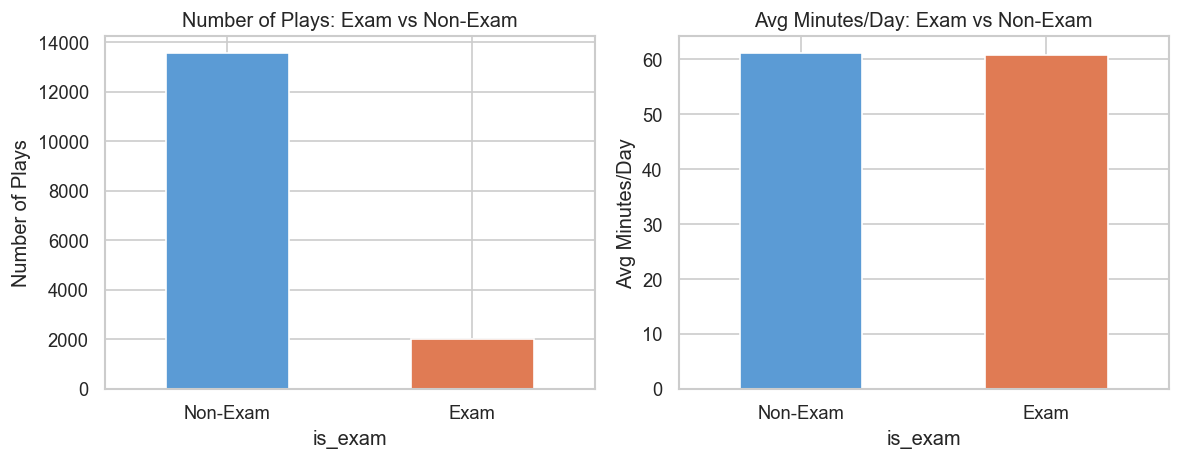

In [7]:
exam_agg = df.groupby('is_exam').agg(
    plays=('track_name','count'),
    total_min=('min_played','sum'),
    avg_min_per_day=('min_played', lambda x: x.sum() / df.loc[x.index, 'date'].nunique())
).rename(index={False:'Non-Exam', True:'Exam'})

print(exam_agg.round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title in zip(axes,
                           ['plays','avg_min_per_day'],
                           ['Number of Plays','Avg Minutes/Day']):
    exam_agg[col].plot(kind='bar', ax=ax, color=['#5b9bd5','#e07b54'], edgecolor='white', rot=0)
    ax.set_title(f'{title}: Exam vs Non-Exam', fontsize=12)
    ax.set_ylabel(title)
plt.tight_layout(); plt.savefig('figures/06_exam_vs_nonexam.png', bbox_inches='tight'); plt.show()

## 7. Top Artists & Tracks

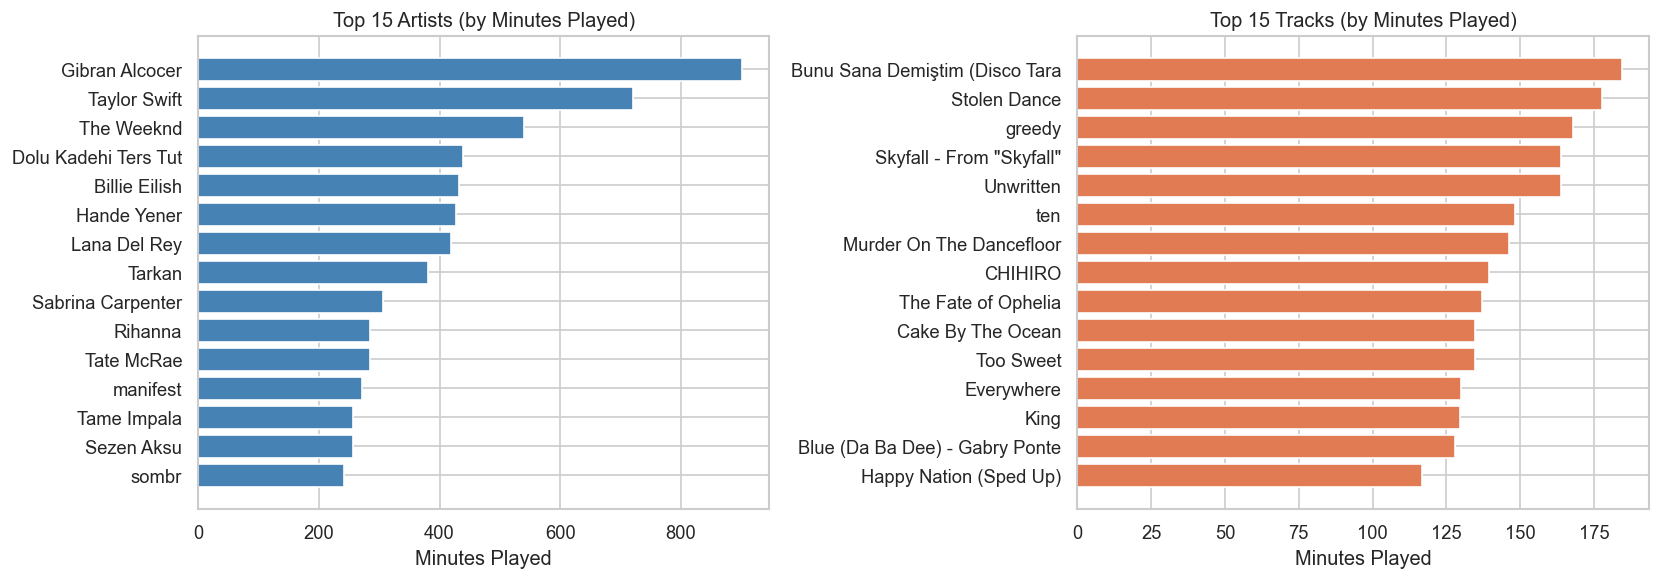

In [8]:
top_artists = df.groupby('artist')['min_played'].sum().nlargest(15).reset_index()
top_tracks  = df.groupby(['track_name','artist'])['min_played'].sum().nlargest(15).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_artists['artist'][::-1], top_artists['min_played'][::-1], color='steelblue')
axes[0].set_title('Top 15 Artists (by Minutes Played)', fontsize=12)
axes[0].set_xlabel('Minutes Played')

labels = [f"{r['track_name'][:30]}" for _, r in top_tracks.iterrows()]
axes[1].barh(labels[::-1], top_tracks['min_played'][::-1], color='#e07b54')
axes[1].set_title('Top 15 Tracks (by Minutes Played)', fontsize=12)
axes[1].set_xlabel('Minutes Played')

plt.tight_layout(); plt.savefig('figures/07_top_artists_tracks.png', bbox_inches='tight'); plt.show()

## 8. Heatmap: Hour × Day of Week

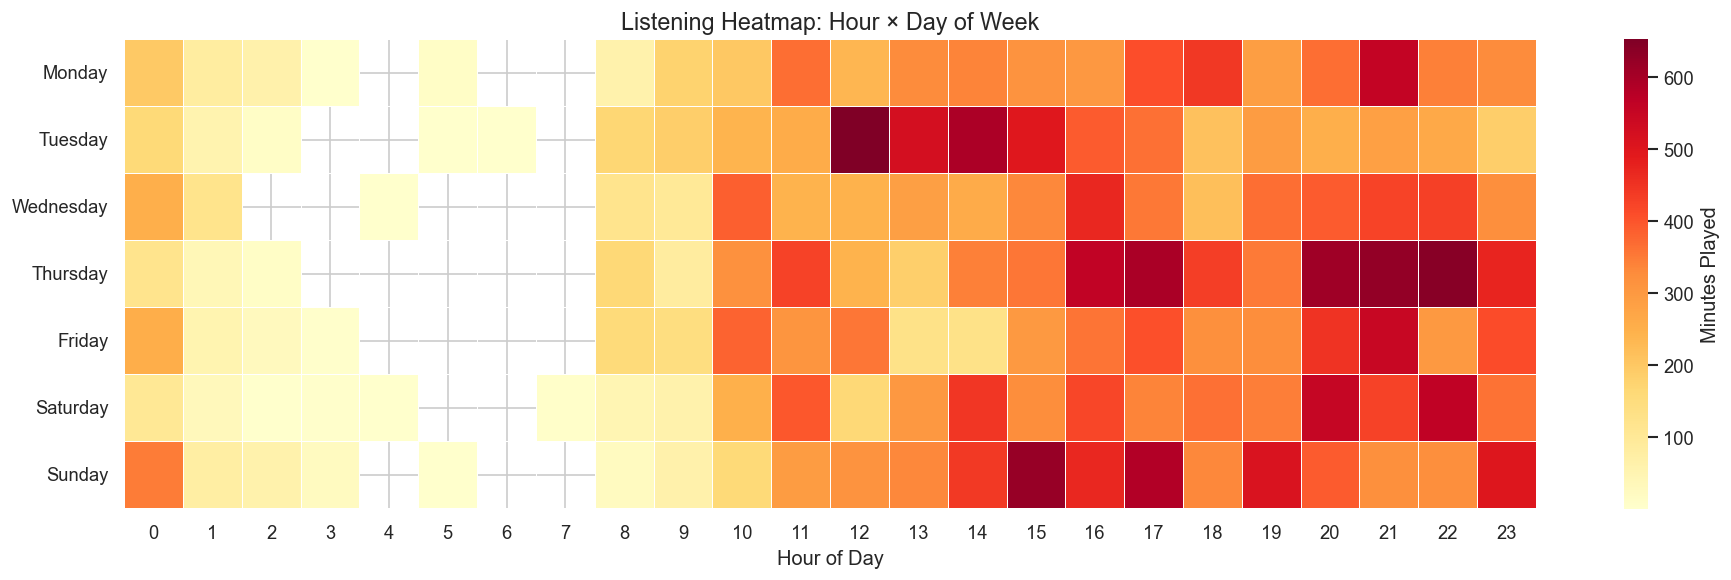

In [9]:
pivot = df.pivot_table(index='day_of_week', columns='hour',
                       values='min_played', aggfunc='sum')
pivot = pivot.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Minutes Played'})
ax.set_title('Listening Heatmap: Hour × Day of Week', fontsize=14)
ax.set_xlabel('Hour of Day'); ax.set_ylabel('')
plt.tight_layout(); plt.savefig('figures/08_heatmap.png', bbox_inches='tight'); plt.show()

## 9. Skip Rate Analysis

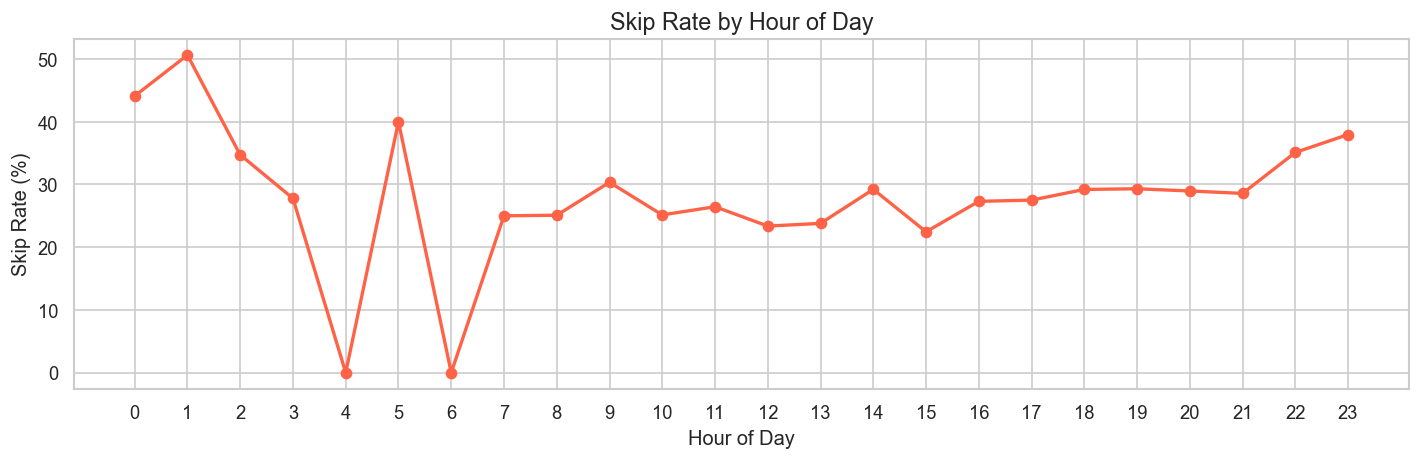

In [10]:
if 'skipped' in df.columns:
    skip_hour = df.groupby('hour')['skipped'].mean() * 100
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(skip_hour.index, skip_hour.values, marker='o', color='tomato', lw=2)
    ax.set_xticks(range(24))
    ax.set_xlabel('Hour of Day'); ax.set_ylabel('Skip Rate (%)')
    ax.set_title('Skip Rate by Hour of Day', fontsize=14)
    plt.tight_layout(); plt.savefig('figures/09_skip_rate.png', bbox_inches='tight'); plt.show()
else:
    print('Skip data not available in this dataset.')